<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


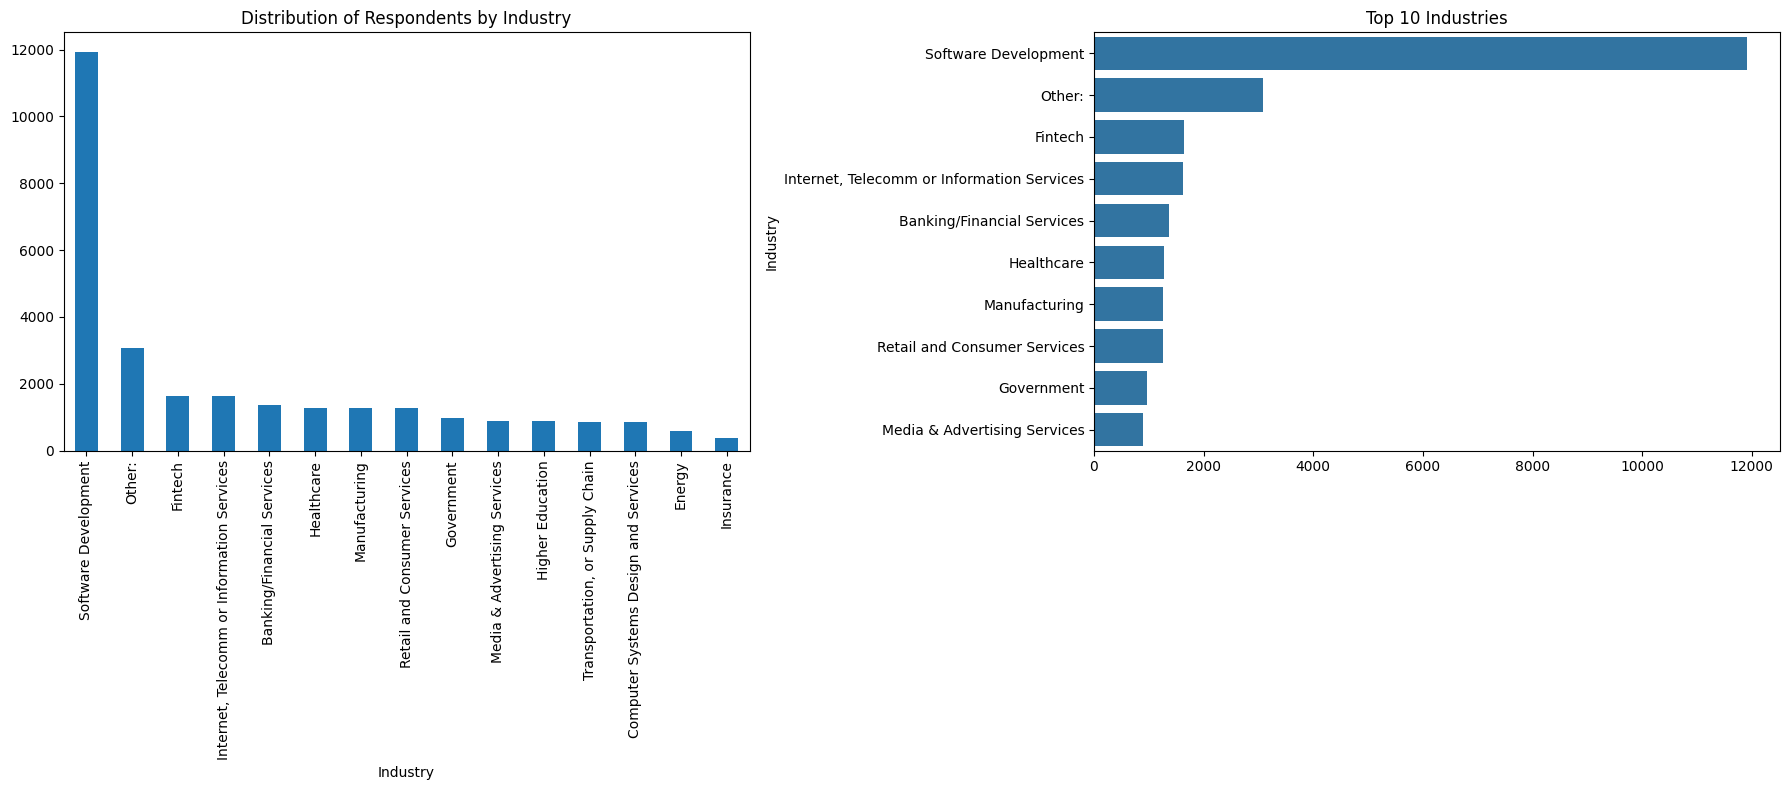

In [3]:
##Write your code here
# Bar chart of industry distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#df['JobSat'].hist(bins=50, ax=axes[0])
df['Industry'].value_counts().head(15).plot(kind='bar',ax=axes[0])
axes[0].set_title('Distribution of Respondents by Industry')

sns.barplot(
    x=df['Industry'].value_counts().head(10).values,
    y=df['Industry'].value_counts().head(10).index,
    ax=axes[1]
)
axes[1].set_title('Top 10 Industries')


plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here
stats = df['ConvertedCompYearly'].agg(['mean', 'median', 'std'])
print(stats)
mean_val = stats['mean']
std_val = stats['std']

# Basic statistics for ConvertedCompYearly
mean = df['ConvertedCompYearly'].mean()
median = df['ConvertedCompYearly'].median()
std = df['ConvertedCompYearly'].std()

print(f"Mean: ${mean:,.2f}")
print(f"Median: ${median:,.2f}")
print(f"Std Dev: ${std:,.2f}")

# Identify outliers — 3 standard deviations above mean
threshold = mean + 3 * std
outliers = df[df['ConvertedCompYearly'] > threshold]
print(f"\nThreshold: ${threshold:,.2f}")
print(f"Number of high compensation outliers: {len(outliers)}")



mean       86155.287263
median     65000.000000
std       186756.973086
Name: ConvertedCompYearly, dtype: float64
Mean: $86,155.29
Median: $65,000.00
Std Dev: $186,756.97

Threshold: $646,426.21
Number of high compensation outliers: 89

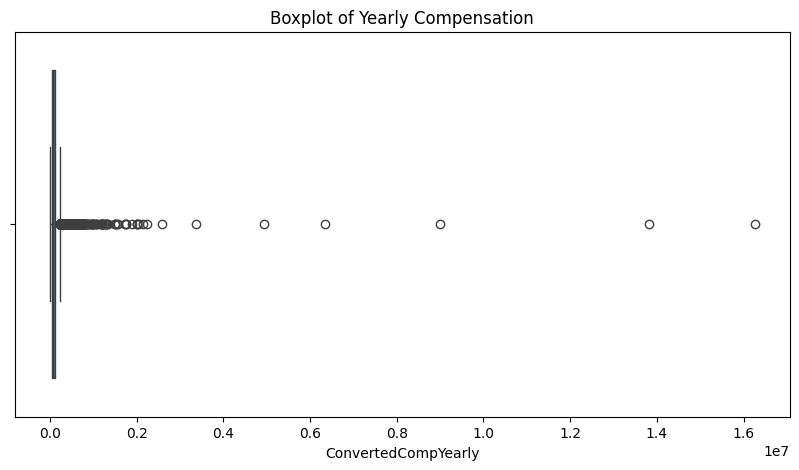

In [5]:
# Optional: Visualize with boxplot
plt.figure(figsize=(10,5))

sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Boxplot of Yearly Compensation')

plt.show()

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower Bound: -80177.25
Upper Bound: 220860.75
     ConvertedCompYearly
428             230000.0
456             300000.0
461             254425.0
529             650000.0
545             400000.0
Number of IQR outliers: 978

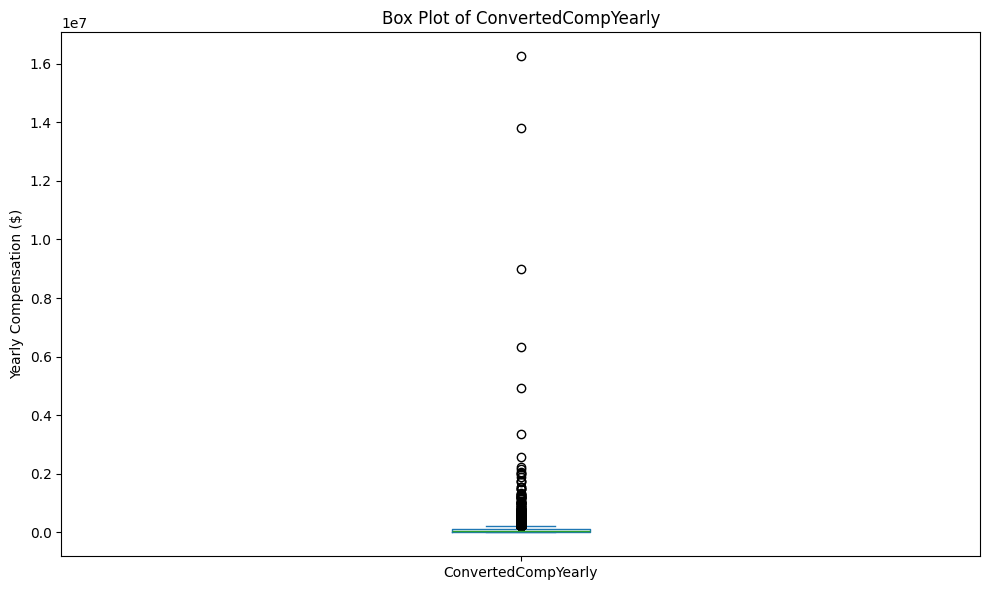

In [6]:
##Write your code here

# Step 1: Calculate Q1 and Q3
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

#Step 2: Calculate IQR
IQR = Q3 - Q1

print("IQR:", IQR)

# Step 3: Define outlier bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Step 4: Identify outliers
iqr_outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) |
    (df['ConvertedCompYearly'] > upper_bound)
]

print(iqr_outliers[['ConvertedCompYearly']].head())

# Step 5: Count outliers
print("Number of IQR outliers:",
      iqr_outliers.shape[0])

# Box plot
plt.figure(figsize=(10, 6))
df['ConvertedCompYearly'].plot(kind='box')
plt.title('Box Plot of ConvertedCompYearly')
plt.ylabel('Yearly Compensation ($)')
plt.tight_layout()
plt.show()


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


Original dataset shape: (65437, 114)
Dataset without outliers: (22457, 114)

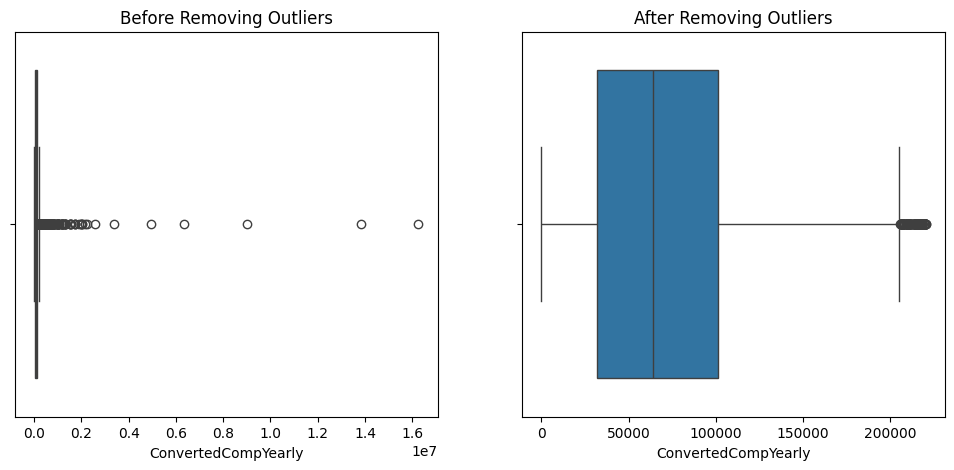

In [7]:
##Write your code here
# Step 1: Create a new dataframe without outliers
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

# Step 2: Validate dataframe size
print("Original dataset shape:", df.shape)
print("Dataset without outliers:", df_no_outliers.shape)
# Step 3: Verify outliers were removed
df_no_outliers[
    (df_no_outliers['ConvertedCompYearly'] < lower_bound) |
    (df_no_outliers['ConvertedCompYearly'] > upper_bound)
].shape

# Compare distributions before and after removal
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title('Before Removing Outliers')

plt.subplot(1,2,2)
sns.boxplot(x=df_no_outliers['ConvertedCompYearly'])
plt.title('After Removing Outliers')

plt.show()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


                     ResponseId  CompTotal   WorkExp  JobSatPoints_1  \
ResponseId             1.000000  -0.000000  0.011955       -0.002406   
CompTotal             -0.000000   0.000000  0.028766       -0.004891   
WorkExp                0.011955   0.028766  1.000000       -0.026490   
JobSatPoints_1        -0.002406  -0.004891 -0.026490        1.000000   
JobSatPoints_4        -0.015738  -0.002719 -0.067241        0.445710   
JobSatPoints_5        -0.014197  -0.003033 -0.104525        0.633765   
JobSatPoints_6        -0.001908  -0.006311 -0.065352        0.618618   
JobSatPoints_7         0.001843  -0.005893 -0.101461        0.603157   
JobSatPoints_8        -0.002968  -0.004585 -0.046958        0.627385   
JobSatPoints_9         0.001991  -0.004494 -0.088090        0.597527   
JobSatPoints_10       -0.005365  -0.003198 -0.113707        0.585087   
JobSatPoints_11       -0.005865  -0.003045 -0.108279        0.607792   
ConvertedCompYearly   -0.008363   0.080457  0.154114        0.02

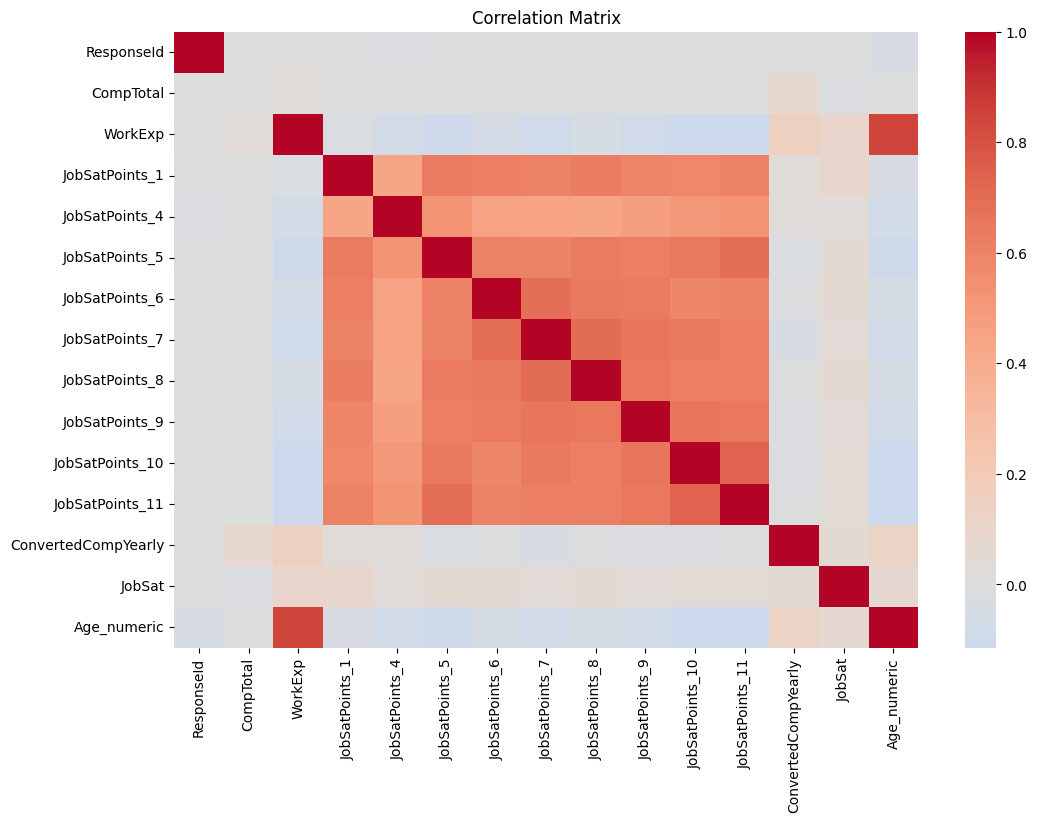

In [8]:
##Write your code here

# Step 1: Map Age categories to numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df['Age_numeric'] = df['Age'].map(age_mapping)

# Step 2: Select numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Step 3: Compute correlation matrix
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

#Step 4: Correlation of Age with other variables
age_correlations = correlation_matrix['Age_numeric'].sort_values(
    ascending=False
)

print(age_correlations)


                     Age_numeric  YearsCodePro  ConvertedCompYearly   WorkExp
Age_numeric             1.000000      0.823719             0.367714  0.846986
YearsCodePro            0.823719      1.000000             0.387209  0.923855
ConvertedCompYearly     0.367714      0.387209             1.000000  0.408438
WorkExp                 0.846986      0.923855             0.408438  1.000000

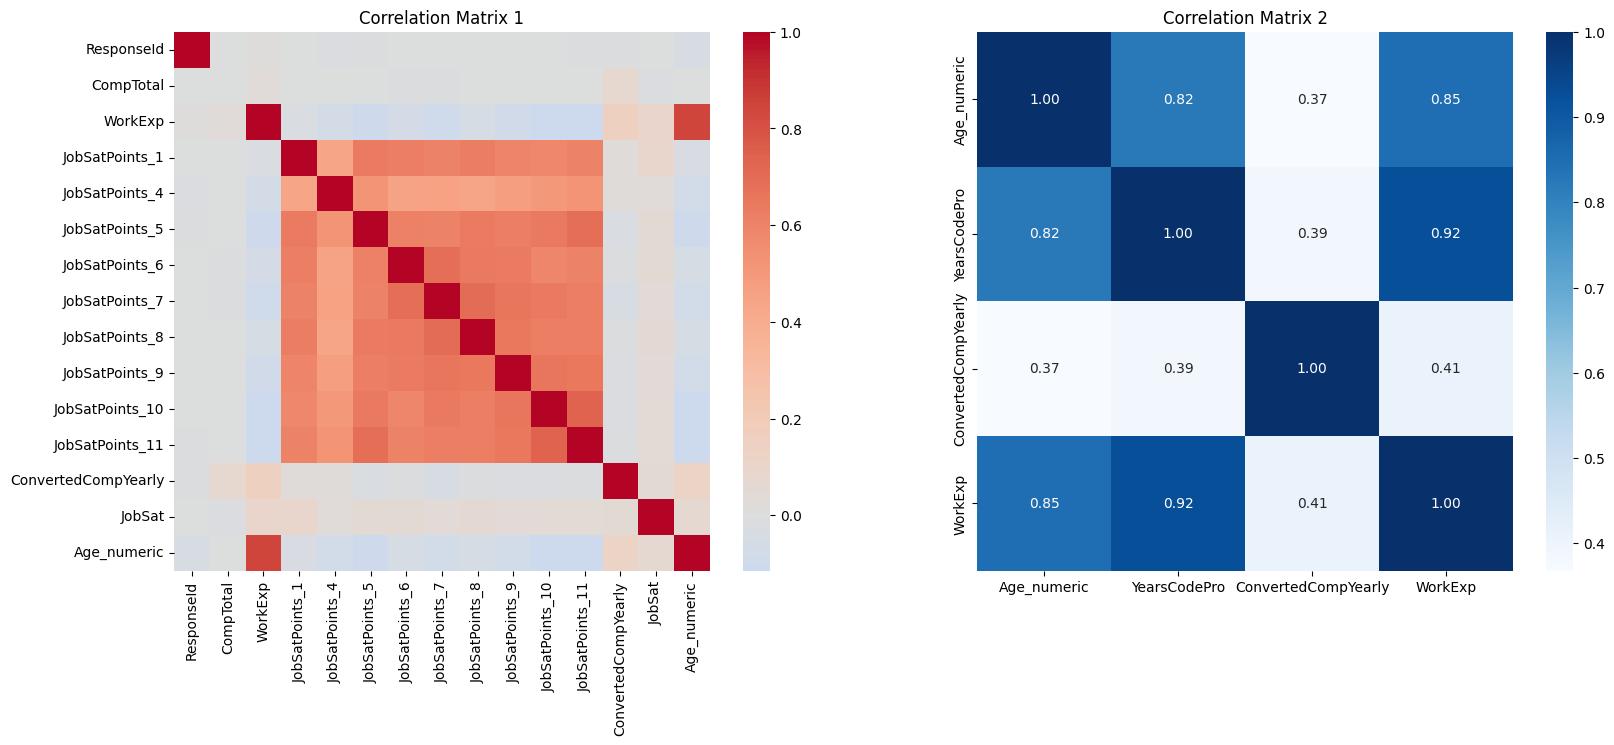

"\nplt.figure(figsize=(12,8))\n\nsns.heatmap(\n    correlation_matrix,\n    cmap='coolwarm',\n    center=0\n)\n\nplt.title('Correlation Matrix')\n\nplt.show()\n\n# Visualize correlation matrix\nplt.figure(figsize=(10, 8))\nsns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues')\nplt.title('Correlation Matrix')\nplt.tight_layout()\nplt.show()\n"

In [13]:
# Map Age to numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}
df_no_outliers['Age_numeric'] = df_no_outliers['Age'].map(age_mapping)

# Compute correlations
numeric_cols = df_no_outliers[['Age_numeric', 'YearsCodePro', 'ConvertedCompYearly', 'WorkExp']].apply(pd.to_numeric, errors='coerce')
corr_matrix = numeric_cols.corr()
print(corr_matrix)

# Step 5: Visualize correlation matrix
plt.figure(figsize=(19,7))

plt.subplot(1,2,1)
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix 1')

plt.subplot(1,2,2)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix 2')

plt.show()

"""
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
"""

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
